

## KPMG GVA Lighthouse – Generative AI Technical Case Study

### Objective

This project evaluates the impact of task-specific fine-tuning on dialogue summarization using the DialogSum dataset.

The experiment uses `google/flan-t5-small` as the base model and compares its summarization performance before and after fine-tuning on dialogue-summary pairs from DialogSum.

The evaluation focuses on both quantitative and qualitative performance. ROUGE and BLEU are used to measure reference-based summarization quality, while embedding-based semantic similarity is used to assess meaning-level alignment. Generated summaries are also manually reviewed to identify limitations such as hallucination, incorrect speaker attribution, repetition, and incomplete information.

The overall objective is to determine whether fine-tuning improves the model's ability to produce relevant and concise dialogue summaries while considering computational efficiency, factual reliability, and practical enterprise applicability.

# 1. Model Selection


Several open-source sequence-to-sequence models were considered for this dialogue summarization task:

- `google-t5/t5-small`
- `google/flan-t5-small`
- `google/flan-t5-base`
- `sshleifer/distilbart-cnn-12-6`

### Model Considerations

`T5-Small` is lightweight and suitable for text-to-text tasks, including summarization, but it does not include instruction tuning.

`FLAN-T5-Small` builds on the T5 encoder-decoder architecture and adds instruction tuning. This provides stronger task-following behavior while maintaining a relatively small computational footprint.

`FLAN-T5-Base` offers greater model capacity, but its increased memory and compute requirements make it less suitable for a laptop-based fine-tuning experiment.

`DistilBART-CNN-12-6` is a strong summarization model, but it is larger and is already heavily specialized for summarization, which makes it less attractive for demonstrating the impact of task-specific adaptation on DialogSum.

### Final Model Selection

The final model selected for this experiment is:

`google/flan-t5-small`

FLAN-T5-Small was chosen because it provides a practical balance between model capability, computational efficiency, and suitability for sequence-to-sequence summarization.

Its encoder-decoder architecture is well suited for abstractive summarization, while its smaller model size makes local fine-tuning and inference feasible on limited hardware.

The model also provides a meaningful baseline because it already has general instruction-following capability but has not been specifically fine-tuned on the DialogSum dialogue summarization dataset.

## 2. Environment and Experiment Configuration

A centralized configuration is used to improve reproducibility and keep model, preprocessing, and training parameters consistent throughout the experiment.

A fixed random seed is applied where supported, and the runtime automatically uses the Apple Silicon MPS backend when available, with CPU as a fallback.

The main model and training parameters are defined once and reused throughout the notebook.

In [5]:
# ============================================================
# Environment and Experiment Configuration
# ============================================================

import random
import numpy as np
import torch

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Model configuration
MODEL_NAME = "google/flan-t5-small"

# Sequence lengths selected based on DialogSum token-length analysis
MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 128

# Training configuration
LEARNING_RATE = 5e-5
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2
NUM_TRAIN_EPOCHS = 3
WEIGHT_DECAY = 0.01

# Select Apple Silicon GPU when available
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Selected device: {DEVICE}")
print(f"Selected model: {MODEL_NAME}")

PyTorch version: 2.13.0
Selected device: mps
Selected model: google/flan-t5-small


## 3. Dataset Loading and Split Strategy

The experiment uses the `knkarthick/dialogsum` dataset from Hugging Face for dialogue summarization.

DialogSum provides predefined training, validation, and test splits:

- **Training:** 12,460 samples
- **Validation:** 500 samples
- **Test:** 1,500 samples

Each split contains:

- `id`
- `dialogue`
- `summary`
- `topic`

For this task:

- `dialogue` is used as the model input.
- `summary` is used as the target output.
- `topic` and `id` are retained during initial exploration but are not required for model training.

The official dataset splits are preserved rather than creating a new random split. This maintains a clear separation between:

- **Training data** for updating model parameters,
- **Validation data** for monitoring generalization during fine-tuning,
- **Test data** for the final baseline and fine-tuned model evaluation.

No test examples are used during model training or hyperparameter updates.

In [6]:
from datasets import load_dataset

# Load DialogSum directly from Hugging Face
dataset = load_dataset("knkarthick/dialogsum")

# Display the complete dataset structure
print(dataset)

print("\nDataset columns by split:")

for split_name in dataset.keys():
    print(
        f"{split_name}: "
        f"{dataset[split_name].column_names}"
    )

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1500
    })
})

Dataset columns by split:
train: ['id', 'dialogue', 'summary', 'topic']
validation: ['id', 'dialogue', 'summary', 'topic']
test: ['id', 'dialogue', 'summary', 'topic']


## 4. Exploratory Data Analysis and Data Quality

Before preprocessing, the dataset is inspected for issues that could affect model training or evaluation.

The following checks are performed:

- missing or empty dialogues,
- missing or empty summaries,
- duplicate dialogues,
- duplicate summaries.

Missing input-target pairs would need to be removed or corrected before training. Duplicate records are inspected separately because repeated dialogues in a summarization dataset may represent multiple valid human-written reference summaries rather than accidental duplication.

In [7]:
# ============================================================
# Data Quality Checks
# ============================================================

for split_name in ["train", "validation", "test"]:
    split = dataset[split_name]

    print(f"\n--- {split_name.upper()} ---")

    # Count missing or empty dialogue values
    missing_dialogues = sum(
        value is None or str(value).strip() == ""
        for value in split["dialogue"]
    )

    # Count missing or empty summary values
    missing_summaries = sum(
        value is None or str(value).strip() == ""
        for value in split["summary"]
    )

    # Count duplicate dialogue records
    duplicate_dialogues = (
        len(split["dialogue"])
        - len(set(split["dialogue"]))
    )

    # Count duplicate summary records
    duplicate_summaries = (
        len(split["summary"])
        - len(set(split["summary"]))
    )

    print(f"Missing dialogues: {missing_dialogues}")
    print(f"Missing summaries: {missing_summaries}")
    print(f"Duplicate dialogues: {duplicate_dialogues}")
    print(f"Duplicate summaries: {duplicate_summaries}")


--- TRAIN ---
Missing dialogues: 0
Missing summaries: 0
Duplicate dialogues: 2
Duplicate summaries: 24

--- VALIDATION ---
Missing dialogues: 0
Missing summaries: 0
Duplicate dialogues: 0
Duplicate summaries: 0

--- TEST ---
Missing dialogues: 0
Missing summaries: 0
Duplicate dialogues: 1000
Duplicate summaries: 13


### Test-Set Duplicate Analysis

The test split contains **1,500 records representing 500 unique dialogues**. Inspection shows that each dialogue is associated with multiple human-written reference summaries.

These records are therefore not treated as accidental duplicates.

Because abstractive summarization can have several valid formulations for the same dialogue, all available reference summaries are retained for evaluation. During benchmarking:

1. the model generates one prediction for each unique test dialogue, and
2. that prediction is evaluated against all available human reference summaries.

This provides a more robust evaluation than arbitrarily selecting or removing valid references.

No missing dialogue or summary values were found across the training, validation, or test splits, so no missing-data removal or imputation was required.

In [8]:
# ============================================================
# Inspect Repeated Dialogues in the Test Split
# ============================================================

from collections import Counter

# Count how many times each dialogue appears in the test set
test_dialogue_counts = Counter(dataset["test"]["dialogue"])

# Keep only dialogues that appear more than once
repeated_dialogues = {
    dialogue: count
    for dialogue, count in test_dialogue_counts.items()
    if count > 1
}

print(f"Unique repeated dialogues: {len(repeated_dialogues)}")

# Inspect one repeated dialogue and all associated summaries
sample_dialogue = next(iter(repeated_dialogues))

print("\nDialogue:")
print(sample_dialogue)

print("\nReference summaries:")

for row in dataset["test"]:
    if row["dialogue"] == sample_dialogue:
        print(f"- {row['summary']}")

Unique repeated dialogues: 500

Dialogue:
#Person1#: Ms. Dawson, I need you to take a dictation for me.
#Person2#: Yes, sir...
#Person1#: This should go out as an intra-office memorandum to all employees by this afternoon. Are you ready?
#Person2#: Yes, sir. Go ahead.
#Person1#: Attention all staff... Effective immediately, all office communications are restricted to email correspondence and official memos. The use of Instant Message programs by employees during working hours is strictly prohibited.
#Person2#: Sir, does this apply to intra-office communications only? Or will it also restrict external communications?
#Person1#: It should apply to all communications, not only in this office between employees, but also any outside communications.
#Person2#: But sir, many employees use Instant Messaging to communicate with their clients.
#Person1#: They will just have to change their communication methods. I don't want any - one using Instant Messaging in this office. It wastes too much ti

### Token-Length Analysis

For sequence-to-sequence models, input and target sequence lengths directly affect memory usage, training speed, and the amount of information preserved during tokenization.

To choose suitable maximum sequence lengths, the training split is tokenized without truncation and the distribution of dialogue and summary token lengths is analyzed.

This analysis is used to determine:

- the maximum input length for dialogue text,
- the maximum target length for reference summaries,
- how much truncation may occur,
- and whether the selected limits provide a reasonable balance between context preservation and computational efficiency.

The training split is used for this analysis because these statistics are primarily needed to configure the preprocessing and fine-tuning pipeline.

In [9]:
# ============================================================
# Token-Length Analysis
# ============================================================

from transformers import AutoTokenizer

# Load the tokenizer associated with the selected model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def get_token_lengths(texts):
    """
    Calculate the number of tokenizer tokens for each text
    without applying truncation.

    This allows us to inspect the true sequence-length
    distribution before selecting preprocessing limits.
    """
    return [
        len(tokenizer(text, truncation=False)["input_ids"])
        for text in texts
    ]


# Measure dialogue and summary lengths from the training split
train_dialogue_lengths = get_token_lengths(
    dataset["train"]["dialogue"]
)

train_summary_lengths = get_token_lengths(
    dataset["train"]["summary"]
)

print("Dialogue token lengths")
print(f"Mean: {np.mean(train_dialogue_lengths):.2f}")
print(f"Median: {np.median(train_dialogue_lengths):.0f}")
print(
    f"95th percentile: "
    f"{np.percentile(train_dialogue_lengths, 95):.2f}"
)
print(
    f"99th percentile: "
    f"{np.percentile(train_dialogue_lengths, 99):.2f}"
)
print(f"Maximum: {max(train_dialogue_lengths)}")

print("\nSummary token lengths")
print(f"Mean: {np.mean(train_summary_lengths):.2f}")
print(f"Median: {np.median(train_summary_lengths):.0f}")
print(
    f"95th percentile: "
    f"{np.percentile(train_summary_lengths, 95):.2f}"
)
print(
    f"99th percentile: "
    f"{np.percentile(train_summary_lengths, 99):.2f}"
)
print(f"Maximum: {max(train_summary_lengths)}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (517 > 512). Running this sequence through the model will result in indexing errors


Dialogue token lengths
Mean: 224.40
Median: 202
95th percentile: 416.00
99th percentile: 614.41
Maximum: 1569

Summary token lengths
Mean: 41.27
Median: 38
95th percentile: 73.00
99th percentile: 96.00
Maximum: 277


### Sequence length selection

Token lengths are analyzed before preprocessing to select practical maximum sequence lengths for training.

The training split shows the following distribution:

| Sequence | Mean | Median | 95th Percentile | 99th Percentile | Maximum |
|---|---:|---:|---:|---:|---:|
| Dialogue | 224.40 | 202 | 416 | 614.41 | 1569 |
| Summary | 41.27 | 38 | 73 | 96 | 277 |

Based on this distribution:

- `MAX_INPUT_LENGTH = 512` is selected for dialogues. This covers the large majority of examples while avoiding the computational cost of padding or processing the longest outliers.
- `MAX_TARGET_LENGTH = 128` is selected for summaries. This comfortably covers more than 99% of the observed target lengths while keeping generation efficient.

Examples exceeding these limits are truncated during tokenization.

This provides a practical balance between retaining dialogue context and keeping training feasible on laptop-class hardware.

## 5. Input Formatting and Tokenization

FLAN-T5 follows a text-to-text sequence-to-sequence architecture, so each dialogue is converted into an instruction-style input and its reference summary is used as the target.

The input format is:

`Summarize the following dialogue: <dialogue>`

Based on the token-length analysis:

- input dialogues are truncated to `512` tokens,
- target summaries are truncated to `128` tokens.

Padding is intentionally deferred to the data collator. Dynamic padding is applied at batch time so that sequences are padded only to the longest example in each batch rather than to the global maximum length.

This reduces unnecessary padding and improves memory efficiency during training.

In [10]:
# ============================================================
# Dataset Preprocessing and Tokenization
# ============================================================

def preprocess_function(examples):
    """
    Convert DialogSum examples into tokenized model inputs
    and target labels for FLAN-T5 fine-tuning.
    """

    # Add a task instruction before each dialogue.
    inputs = [
        "Summarize the following dialogue: " + dialogue
        for dialogue in examples["dialogue"]
    ]

    # Tokenize dialogue inputs.
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    )

    # Tokenize reference summaries as target labels.
    labels = tokenizer(
        text_target=examples["summary"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True
    )

    # Attach the target token IDs as training labels.
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs


# Apply preprocessing to all dataset splits.
tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset["train"].column_names
)

print(tokenized_dataset)

Map:   0%|          | 0/12460 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 500
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1500
    })
})


## 6. Model Loading and Dynamic Padding

The pretrained `google/flan-t5-small` sequence-to-sequence model is loaded and moved to the configured execution device.

`DataCollatorForSeq2Seq` is used for dynamic padding. Instead of padding every example to the global maximum sequence length, each batch is padded only to the longest input and target sequence within that batch.

This reduces unnecessary memory and computation while correctly preparing variable-length inputs and labels for sequence-to-sequence training.

In [12]:
# ============================================================
# Model Loading and Dynamic Padding
# ============================================================

from transformers import (
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq
)

# Load the pretrained FLAN-T5-Small sequence-to-sequence model.
model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME
)

# Move the model to the configured execution device.
model = model.to(DEVICE)

# Configure dynamic padding for both model inputs and labels.
#
# Each batch will be padded only to the longest sequence
# contained within that batch rather than to the global
# maximum sequence length.
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

print(f"Model loaded: {MODEL_NAME}")
print(f"Model device: {DEVICE}")
print("Data collator configured successfully.")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model loaded: google/flan-t5-small
Model device: mps
Data collator configured successfully.




## 7. Baseline Inference

Before fine-tuning, the pretrained `google/flan-t5-small` model is evaluated on the DialogSum test set to establish a performance baseline.

The baseline is evaluated using the same prompt structure, sequence limits, test dialogues, and decoding configuration that will later be used for the fine-tuned models. This ensures that any performance difference can be attributed primarily to task-specific fine-tuning rather than changes in inference settings.

A small qualitative check is performed first to inspect model behavior, followed by quantitative evaluation across all 500 unique test dialogues.

In [13]:
# ============================================================
# Baseline Summary Generation
# ============================================================

def generate_summary(dialogue):
    """
    Generate a dialogue summary using the current model.

    The same function will be reused after fine-tuning so that
    the baseline and fine-tuned models are evaluated using
    identical generation settings.
    """

    # Format the dialogue using the same instruction structure
    # used during dataset preprocessing.
    prompt = (
        "Summarize the following dialogue: "
        + dialogue
    )

    # Convert the text prompt into model-ready tensors.
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    ).to(DEVICE)

    # Disable gradient calculation because inference does not
    # require backpropagation.
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_TARGET_LENGTH,
            num_beams=4
        )

    # Convert generated token IDs back into readable text.
    summary = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    return summary

### Baseline Qualitative Check

Three unique test dialogues are inspected before running the full benchmark.

This check provides an initial view of whether the pretrained model follows the summarization task correctly and highlights typical weaknesses before task-specific fine-tuning.

The full quantitative evaluation is performed separately across all unique test dialogues.

In [14]:
# ============================================================
# Qualitative Baseline Inspection
# ============================================================

seen_dialogues = set()
sample_count = 0

for example in dataset["test"]:
    dialogue = example["dialogue"]

    # Skip repeated dialogues so that each displayed example
    # represents a different conversation.
    if dialogue in seen_dialogues:
        continue

    seen_dialogues.add(dialogue)

    # Generate a summary using the pretrained baseline model.
    baseline_prediction = generate_summary(dialogue)

    print(f"\n--- Baseline Sample {sample_count + 1} ---")

    print("\nReference Summary:")
    print(example["summary"])

    print("\nBaseline FLAN-T5-Small Summary:")
    print(baseline_prediction)

    sample_count += 1

    # Display only three unique examples for readability.
    if sample_count == 3:
        break


--- Baseline Sample 1 ---

Reference Summary:
Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.

Baseline FLAN-T5-Small Summary:
#Person2#: Thank you, sir.

--- Baseline Sample 2 ---

Reference Summary:
#Person2# arrives late because of traffic jam. #Person1# persuades #Person2# to use public transportations to keep healthy and to protect the environment.

Baseline FLAN-T5-Small Summary:
Taking the subway would be a lot less stressful than driving.

--- Baseline Sample 3 ---

Reference Summary:
#Person1# tells Kate that Masha and Hero get divorced. Kate is surprised because she thought they are perfect couple.

Baseline FLAN-T5-Small Summary:
Masha and Hero are getting divorced.


### Baseline Qualitative Observations

The pretrained model shows inconsistent dialogue summarization behavior.

Across the inspected examples:

- one output behaves more like a dialogue continuation than a summary,
- one captures only part of the relevant information,
- and one identifies the main event but is overly brief.

This suggests that FLAN-T5-Small has general text-generation and summarization capability, but has not yet adapted reliably to the structure and expectations of DialogSum.

### Preparing the Test Set for Multi-Reference Evaluation

The DialogSum test split contains repeated dialogues with multiple independently written reference summaries.

To avoid generating the same model output multiple times for an identical dialogue, the test split is reorganized so that each unique dialogue appears once and is associated with all of its available reference summaries.

This creates a fair evaluation structure:

- One generated summary per unique dialogue
- Multiple human reference summaries for comparison

Using multiple references is particularly useful for abstractive summarization because different human-written summaries can express the same meaning using different wording.

In [16]:
# ============================================================
# Prepare Unique Test Dialogues and Multiple References
# ============================================================

from collections import defaultdict

# Group all reference summaries belonging to the same dialogue.
test_references = defaultdict(list)

for row in dataset["test"]:
    test_references[row["dialogue"]].append(
        row["summary"]
    )

# Create a list containing each unique dialogue once.
unique_test_dialogues = list(test_references.keys())

print(
    f"Original test records: "
    f"{len(dataset['test'])}"
)

print(
    f"Unique test dialogues: "
    f"{len(unique_test_dialogues)}"
)

# Confirm the number of references available for one dialogue.
sample_dialogue = unique_test_dialogues[0]

print(
    f"Reference summaries for first dialogue: "
    f"{len(test_references[sample_dialogue])}"
)

Original test records: 1500
Unique test dialogues: 500
Reference summaries for first dialogue: 3


## 8. Baseline Quantitative Evaluation

The pretrained baseline model is evaluated on all **500 unique test dialogues** using the available human reference summaries.

To capture different aspects of summarization quality, three complementary evaluation approaches are used:

- **ROUGE** measures lexical overlap between the generated and reference summaries, with particular emphasis on unigram, bigram, and longest-common-subsequence overlap.
- **BLEU** measures n-gram precision between generated and reference text and provides an additional signal for phrase-level similarity.
- **Semantic Similarity** measures how closely the meaning of the generated summary aligns with the reference summaries using sentence embeddings.

Because each test dialogue has multiple valid reference summaries, the prediction for each dialogue is evaluated against all available references.

These metrics are interpreted together rather than individually because lexical overlap alone does not guarantee semantic accuracy or factual correctness.

In [18]:
import evaluate

# Load reference-based evaluation metrics.
rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("sacrebleu")

print("ROUGE and BLEU metrics loaded successfully.")

ROUGE and BLEU metrics loaded successfully.


### Generating Baseline Predictions

The pretrained FLAN-T5-Small model is now used to generate summaries for all 500 unique test dialogues.

The same generation function and decoding configuration used during the qualitative check are retained to ensure consistency.

Each generated summary is stored together with the corresponding set of human reference summaries so that the baseline can be evaluated quantitatively using multiple metrics.

In [21]:
from tqdm.auto import tqdm

# ============================================================
# Generate Baseline Predictions for the Full Test Set
# ============================================================

baseline_predictions = []
baseline_references = []

# Set the model to evaluation mode.
model.eval()

# Generate one summary for each unique test dialogue.
for dialogue in tqdm(
    unique_test_dialogues,
    desc="Generating baseline summaries"
):
    prediction = generate_summary(dialogue)

    baseline_predictions.append(prediction)

    # Preserve all human-written references for this dialogue.
    baseline_references.append(
        test_references[dialogue]
    )

print(
    f"Baseline predictions generated: "
    f"{len(baseline_predictions)}"
)

print(
    f"Reference groups prepared: "
    f"{len(baseline_references)}"
)

Generating baseline summaries:   0%|          | 0/500 [00:00<?, ?it/s]

Baseline predictions generated: 500
Reference groups prepared: 500


### Baseline ROUGE and BLEU Evaluation

The generated baseline summaries are evaluated against the available human reference summaries using ROUGE and BLEU.

ROUGE provides several complementary views of summary overlap:

- **ROUGE-1** measures unigram overlap.
- **ROUGE-2** measures bigram overlap.
- **ROUGE-L** measures similarity based on the longest common subsequence.
- **ROUGE-Lsum** is a summary-oriented variant of ROUGE-L.

BLEU measures n-gram overlap between generated summaries and reference summaries.

These values represent the pretrained FLAN-T5-Small performance before any task-specific fine-tuning.

In [22]:
# ============================================================
# Baseline ROUGE Evaluation
# ============================================================

baseline_rouge = rouge_metric.compute(
    predictions=baseline_predictions,
    references=baseline_references,
    use_stemmer=True
)

print("Baseline ROUGE Scores")

for metric_name, score in baseline_rouge.items():
    print(f"{metric_name}: {score:.4f}")


# ============================================================
# Baseline BLEU Evaluation
# ============================================================

baseline_bleu = bleu_metric.compute(
    predictions=baseline_predictions,
    references=baseline_references
)

print("\nBaseline BLEU Score")
print(f"BLEU: {baseline_bleu['score']:.2f}")

Baseline ROUGE Scores
rouge1: 0.2193
rouge2: 0.0811
rougeL: 0.1932
rougeLsum: 0.1934

Baseline BLEU Score
BLEU: 6.96


### Baseline Semantic Similarity Evaluation

ROUGE and BLEU mainly measure lexical and n-gram overlap between generated summaries and human references. However, two summaries can express the same meaning using different wording.

To complement these overlap-based metrics, semantic similarity is measured using sentence embeddings.

The generated summaries and reference summaries are converted into dense vector representations using the `all-MiniLM-L6-v2` Sentence Transformer model.

Cosine similarity is then calculated between the generated summary embedding and each available human reference embedding.

Because each test dialogue has multiple valid reference summaries, the highest cosine similarity score across the available references is retained for that dialogue.

A higher cosine similarity score indicates that the generated summary is closer in meaning to at least one valid human-written reference.

This metric is used as an additional semantic evaluation signal and should not be interpreted as a direct factual-consistency or hallucination metric.

In [23]:
# ============================================================
# Baseline Semantic Similarity Evaluation
# ============================================================

from sentence_transformers import SentenceTransformer
import numpy as np

# Load a lightweight sentence embedding model.
semantic_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)


def calculate_semantic_similarity(
    predictions,
    references,
    embedding_model
):
    """
    Calculate semantic similarity between generated summaries
    and multiple human reference summaries.

    For each prediction:
    1. Generate a normalized sentence embedding.
    2. Generate embeddings for all available references.
    3. Compute cosine similarity.
    4. Retain the highest similarity score.

    Since the embeddings are normalized, the dot product is
    equivalent to cosine similarity.
    """

    similarity_scores = []

    for prediction, reference_list in zip(
        predictions,
        references
    ):

        # Encode the generated summary.
        prediction_embedding = embedding_model.encode(
            prediction,
            normalize_embeddings=True
        )

        # Encode all human reference summaries.
        reference_embeddings = embedding_model.encode(
            reference_list,
            normalize_embeddings=True
        )

        # Compare the prediction against every reference.
        similarities = np.dot(
            reference_embeddings,
            prediction_embedding
        )

        # Keep the closest matching human reference.
        best_similarity = np.max(similarities)

        similarity_scores.append(best_similarity)

    return np.array(similarity_scores)


# Calculate semantic similarity for the baseline model.
baseline_semantic_scores = calculate_semantic_similarity(
    baseline_predictions,
    baseline_references,
    semantic_model
)

baseline_semantic_similarity = np.mean(
    baseline_semantic_scores
)

print(
    "Baseline Semantic Similarity: "
    f"{baseline_semantic_similarity:.4f}"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Baseline Semantic Similarity: 0.4438


### Baseline Evaluation – Interpretation

The pretrained FLAN-T5-Small model provides a useful reference point before task-specific fine-tuning.

The baseline scores are:

- ROUGE-1: `0.2193`
- ROUGE-2: `0.0811`
- ROUGE-L: `0.1932`
- ROUGE-Lsum: `0.1934`
- BLEU: `6.96`
- Semantic Similarity: `0.4438`

These results indicate that the pretrained model captures some important dialogue information but has limited consistency in producing summaries that closely align with the human references.

The relatively low ROUGE-2 and BLEU scores suggest weak phrase-level alignment, while the semantic similarity score indicates that the generated summaries only partially preserve the intended meaning of the reference summaries.

The qualitative examples support the same conclusion. In some cases, the baseline model produced a relevant but incomplete summary, while in other cases it behaved more like a dialogue continuation model rather than a summarization model.

These baseline results will be used as the benchmark for measuring the impact of fine-tuning on DialogSum.

## 9. Fine-Tuning Strategy and Hyperparameter Selection

The selected `google/flan-t5-small` model is fine-tuned using full parameter updates rather than PEFT.

Full fine-tuning is practical for this experiment because FLAN-T5-Small is sufficiently lightweight to train locally on the available Apple Silicon hardware. Using full fine-tuning also allows the model to adapt all parameters directly to the DialogSum summarization task.

The initial training configuration uses:

| Hyperparameter | Value | Rationale |
|---|---:|---|
| Learning rate | `5e-5` | Conservative learning rate suitable for adapting a pretrained transformer without making overly large parameter updates. |
| Training batch size | `4` | Selected to remain within local memory constraints. |
| Gradient accumulation | `2` | Produces an effective batch size of `8` while keeping per-step memory usage manageable. |
| Epochs | `3` | Used as the initial training duration to evaluate task adaptation while limiting unnecessary training. |
| Weight decay | `0.01` | Provides mild regularization during fine-tuning. |
| Evaluation frequency | Every epoch | Allows validation loss to be monitored throughout training. |
| Checkpoint frequency | Every epoch | Preserves intermediate training states for reproducibility and comparison. |

The validation split is used only for monitoring model generalization during training, while the test split remains isolated for final benchmarking.

An additional 5-epoch experiment is performed later to determine whether extending training provides meaningful improvement or begins to introduce overfitting.

### Training Configuration

The training configuration is implemented using Hugging Face `Seq2SeqTrainingArguments`.

Evaluation and checkpointing are performed at the end of each epoch so that validation performance can be monitored during training. Only a limited number of checkpoints are retained to reduce local storage usage.

The initial experiment trains for three epochs, followed later by a separate five-epoch experiment to evaluate whether additional training provides further improvement.

### Trainer Setup

The Hugging Face `Seq2SeqTrainer` is used to manage the fine-tuning workflow.

It combines the model, training arguments, tokenized training and validation datasets, and the sequence-to-sequence data collator into a single training pipeline.

The training split is used to update model parameters, while the validation split is used to monitor generalization after each epoch.

In [70]:
# ============================================================
# Seq2Seq Trainer Setup
# ============================================================

from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,

    # Tokenized datasets used for training and validation.
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    # Current Hugging Face API for tokenizer/processor handling.
    processing_class=tokenizer,

    # Dynamically pads input and target sequences per batch.
    data_collator=data_collator
)

print("Seq2SeqTrainer configured successfully.")

Seq2SeqTrainer configured successfully.


### Pre-Training Batch Validation

Before starting fine-tuning, a small batch is passed through the sequence-to-sequence data collator to verify that the preprocessing pipeline produces the expected tensors.

The check confirms that:

- `input_ids` and `attention_mask` are correctly created,
- target summaries are stored in `labels`,
- variable-length sequences are dynamically padded,
- padded label positions are masked with `-100`, so they are ignored during loss calculation,
- and decoder inputs are prepared correctly for sequence-to-sequence training.

This sanity check reduces the risk of preprocessing or batching errors before launching the full training run.

In [28]:
# ============================================================
# Pre-Training Batch Sanity Check
# ============================================================

# Create a small batch from two training examples.
sample_batch = data_collator([
    tokenized_dataset["train"][0],
    tokenized_dataset["train"][1]
])

print("Batch keys:", sample_batch.keys())
print("Input IDs shape:", sample_batch["input_ids"].shape)
print("Attention mask shape:", sample_batch["attention_mask"].shape)
print("Labels shape:", sample_batch["labels"].shape)

Batch keys: KeysView({'input_ids': tensor([[12198,  1635,  1737,     8,   826,  7478,    10,  1713,   345, 13515,
           536,  4663,    10,  2018,     6,  1363,     5,  3931,     5,    27,
            31,    51,  7582, 12833,    77,     7,     5,  1615,    33,    25,
           270,   469,    58,  1713,   345, 13515,   357,  4663,    10,    27,
           435,    34,   133,    36,     3,     9,   207,   800,    12,   129,
             3,     9,   691,    18,   413,     5,  1713,   345, 13515,   536,
          4663,    10,  2163,     6,   168,     6,    25,    43,    29,    31,
            17,   141,    80,    21,   305,   203,     5,   148,   225,    43,
            80,   334,   215,     5,  1713,   345, 13515,   357,  4663,    10,
            27,   214,     5,    27,  2320,    38,   307,    38,   132,    19,
          1327,  1786,     6,   572,   281,   217,     8,  2472,    58,  1713,
           345, 13515,   536,  4663,    10,  1548,     6,     8,   200,   194,
            12,  

### Fine-Tuning Execution

The model is fine-tuned on the DialogSum training split using the previously defined configuration.

During training, model parameters are updated using the training data, while validation loss is evaluated at the end of each epoch to monitor generalization.

Training progress and checkpoints are recorded throughout the run.

In [ ]:
# ============================================================
# Fine-Tune FLAN-T5-Small for 3 Epochs
# ============================================================

train_result = trainer.train()

print("Training completed successfully.")



/Users/shashankkowtharapu/Desktop/KPMG/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,2.777654,1.229441
2,2.667694,1.190611
3,2.580363,1.185768


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/shashankkowtharapu/Desktop/KPMG/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/shashankkowtharapu/Desktop/KPMG/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed successfully.


### Training Loss Analysis

The 3-epoch training run shows a consistent reduction in both training and validation loss.

| Epoch | Training Loss | Validation Loss |
|------:|--------------:|----------------:|
| 1 | 2.7777 | 1.2294 |
| 2 | 2.6677 | 1.1906 |
| 3 | 2.5804 | 1.1858 |

Training loss decreases across all three epochs, indicating that the model is adapting to the dialogue summarization task.

Validation loss also decreases from `1.2294` to `1.1858`, which suggests that performance is improving on unseen validation data rather than only on the training set.

No clear overfitting is observed during the initial three epochs because validation loss continues to decrease.

The smaller improvement between epochs 2 and 3 suggests that training may be approaching a plateau. This motivates the later 5-epoch experiment to determine whether additional training provides further gains.

### Saving the 3-Epoch Fine-Tuned Model

The 3-epoch checkpoint is saved so that the exact model used for evaluation can be preserved independently of the later extended-training experiment.

The tokenizer is saved with the model to ensure that the checkpoint can be reloaded with the same preprocessing configuration.

In [30]:
# ============================================================
# Save the 3-Epoch Fine-Tuned Model
# ============================================================

THREE_EPOCH_MODEL_PATH = "./flan-t5-dialogsum-3epoch-final"

# Save model weights and configuration.
trainer.save_model(THREE_EPOCH_MODEL_PATH)

# Save tokenizer files.
tokenizer.save_pretrained(THREE_EPOCH_MODEL_PATH)

print(
    f"3-epoch fine-tuned model saved to: "
    f"{THREE_EPOCH_MODEL_PATH}"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

3-epoch fine-tuned model saved to: ./flan-t5-dialogsum-3epoch-final


## 10. Fine-Tuned Model Evaluation

The 3-epoch fine-tuned model is evaluated on the same **500 unique test dialogues** used for the baseline benchmark.

The same reference summaries, generation settings, and evaluation metrics are retained to ensure a fair comparison with the pretrained model.

Evaluation includes:

- ROUGE
- BLEU
- Semantic Similarity

In [31]:
# ============================================================
# Generate Predictions Using the 3-Epoch Fine-Tuned Model
# ============================================================

fine_tuned_predictions = []
fine_tuned_references = []

# Ensure the model is in evaluation mode.
model.eval()

for dialogue in tqdm(
    unique_test_dialogues,
    desc="Generating fine-tuned summaries"
):
    prediction = generate_summary(dialogue)

    fine_tuned_predictions.append(prediction)

    # Reuse the same reference groups as the baseline.
    fine_tuned_references.append(
        test_references[dialogue]
    )

print(
    f"Fine-tuned predictions generated: "
    f"{len(fine_tuned_predictions)}"
)

print(
    f"Reference groups prepared: "
    f"{len(fine_tuned_references)}"
)

Generating fine-tuned summaries:   0%|          | 0/500 [00:00<?, ?it/s]

Fine-tuned predictions generated: 500
Reference groups prepared: 500


In [32]:
# ============================================================
# Fine-Tuned ROUGE Evaluation
# ============================================================

fine_tuned_rouge = rouge_metric.compute(
    predictions=fine_tuned_predictions,
    references=fine_tuned_references,
    use_stemmer=True
)

print("Fine-Tuned ROUGE Scores")

for metric_name, score in fine_tuned_rouge.items():
    print(f"{metric_name}: {score:.4f}")


# ============================================================
# Fine-Tuned BLEU Evaluation
# ============================================================

fine_tuned_bleu = bleu_metric.compute(
    predictions=fine_tuned_predictions,
    references=fine_tuned_references
)

print("\nFine-Tuned BLEU Score")
print(f"BLEU: {fine_tuned_bleu['score']:.2f}")

Fine-Tuned ROUGE Scores
rouge1: 0.4808
rouge2: 0.2304
rougeL: 0.3989
rougeLsum: 0.3987

Fine-Tuned BLEU Score
BLEU: 25.89


In [33]:
# ============================================================
# Fine-Tuned Semantic Similarity Evaluation
# ============================================================

fine_tuned_semantic_scores = calculate_semantic_similarity(
    fine_tuned_predictions,
    fine_tuned_references,
    semantic_model
)

fine_tuned_semantic_similarity = np.mean(
    fine_tuned_semantic_scores
)

print(
    "Fine-Tuned Semantic Similarity: "
    f"{fine_tuned_semantic_similarity:.4f}"
)

Fine-Tuned Semantic Similarity: 0.7817


## 11. Baseline vs 3-Epoch Fine-Tuned Performance

The pretrained baseline and the 3-epoch fine-tuned FLAN-T5-Small model are compared using the same test dialogues, reference summaries, generation configuration, and evaluation metrics.

This intermediate comparison verifies whether task-specific fine-tuning improves dialogue summarization before evaluating the extended 5-epoch experiment.

In [35]:
import pandas as pd

# ============================================================
# Baseline vs Fine-Tuned Metric Comparison
# ============================================================

results_comparison = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "ROUGE-Lsum",
        "BLEU",
        "Semantic Similarity"
    ],
    "Baseline": [
        baseline_rouge["rouge1"],
        baseline_rouge["rouge2"],
        baseline_rouge["rougeL"],
        baseline_rouge["rougeLsum"],
        baseline_bleu["score"],
        baseline_semantic_similarity
    ],
    "Fine-Tuned (3 Epochs)": [
        fine_tuned_rouge["rouge1"],
        fine_tuned_rouge["rouge2"],
        fine_tuned_rouge["rougeL"],
        fine_tuned_rouge["rougeLsum"],
        fine_tuned_bleu["score"],
        fine_tuned_semantic_similarity
    ]
})

results_comparison["Absolute Improvement"] = (
    results_comparison["Fine-Tuned (3 Epochs)"]
    - results_comparison["Baseline"]
)

results_comparison

,Metric,Baseline,Fine-Tuned (3 Epochs),Absolute Improvement
0,ROUGE-1,0.219324,0.480798,0.261474
1,ROUGE-2,0.081079,0.230396,0.149317
2,ROUGE-L,0.193171,0.398909,0.205738
3,ROUGE-Lsum,0.193417,0.398732,0.205315
4,BLEU,6.955787,25.886773,18.930986
5,Semantic Similarity,0.443796,0.781746,0.337950


### Performance Comparison – Interpretation

The 3-epoch fine-tuned model outperformed the pretrained baseline across all evaluation metrics.

The improvement is substantial across ROUGE, BLEU, and semantic similarity, confirming that task-specific fine-tuning significantly improves FLAN-T5-Small's ability to summarize DialogSum conversations.

Semantic similarity increased from `0.4438` to `0.7817`, indicating that the improvement extends beyond lexical overlap to stronger meaning-level alignment with the human reference summaries.

However, these metrics do not directly guarantee factual correctness. Qualitative evaluation is therefore used later to examine speaker attribution, missing information, repetition, and hallucination.

### Training and Validation Loss

Training loss and validation loss are visualized across epochs to assess whether the model is learning effectively and whether overfitting is beginning to occur.

A decreasing training loss indicates that the model is fitting the training data more effectively.

Validation loss is especially important because it measures performance on unseen validation examples. If training loss continues to decrease while validation loss begins to increase, that can indicate overfitting.

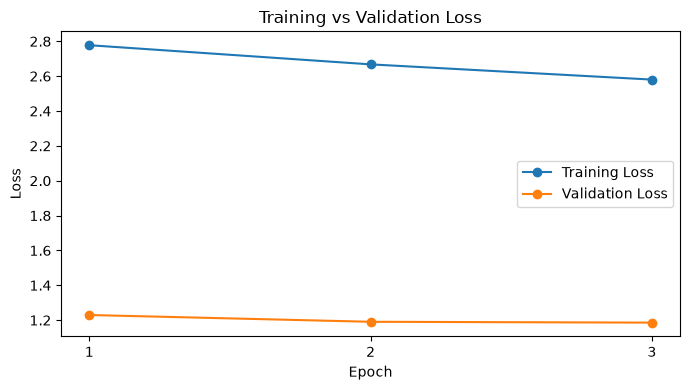

In [41]:
# ============================================================
# Training and Validation Loss Visualization
# ============================================================

epochs = [1, 2, 3]

training_loss = [
    2.777654,
    2.667694,
    2.580363
]

validation_loss = [
    1.229441,
    1.190611,
    1.185768
]

plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.xticks(epochs)
plt.legend()

plt.tight_layout()
plt.show()

## 12. Qualitative Comparison of Generated Summaries

Quantitative metrics provide an aggregate view of summarization quality, but they do not fully capture issues such as incomplete information, incorrect speaker attribution, repetition, or unsupported details.

To complement the metric-based evaluation, the pretrained baseline and the 3-epoch fine-tuned model are compared on the same test dialogues.

This qualitative review focuses on:

- relevance to the source dialogue,
- completeness of important information,
- speaker and entity attribution,
- clarity and conciseness,
- and factual consistency.

The purpose is not to replace the quantitative evaluation, but to identify failure modes that reference-based metrics may not reveal.

In [42]:
# ============================================================
# Baseline vs Fine-Tuned Qualitative Comparison
# ============================================================

comparison_samples = []

# Use the first three unique test dialogues for readability.
for i in range(3):
    comparison_samples.append({
        "dialogue": unique_test_dialogues[i],
        "reference": baseline_references[i][0],
        "baseline": baseline_predictions[i],
        "fine_tuned": fine_tuned_predictions[i]
    })


for i, sample in enumerate(comparison_samples, start=1):

    print("\n" + "=" * 80)
    print(f"SAMPLE {i}")
    print("=" * 80)

    print("\nReference Summary:")
    print(sample["reference"])

    print("\nBaseline Summary:")
    print(sample["baseline"])

    print("\nFine-Tuned Summary:")
    print(sample["fine_tuned"])


SAMPLE 1

Reference Summary:
Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.

Baseline Summary:
#Person2#: Thank you, sir.

Fine-Tuned Summary:
Ms. Dawson asks Ms. Dawson to take a dictation for Ms. Dawson. Ms. Dawson tells Ms. Dawson that all office communications are restricted to email correspondence and official memos. Ms. Dawson tells Ms. Dawson that the use of instant messaging programs by employees during working hours is strictly prohibited.

SAMPLE 2

Reference Summary:
#Person2# arrives late because of traffic jam. #Person1# persuades #Person2# to use public transportations to keep healthy and to protect the environment.

Baseline Summary:
Taking the subway would be a lot less stressful than driving.

Fine-Tuned Summary:
#Person2# got stuck in traffic again because there was a terrible traffic jam near the Carrefour intersection. #Person1# thinks it would be be

## 13. Extended Training Experiment – 5 Epochs

The initial 3-epoch experiment improved both training and validation loss, but the validation improvement between epochs 2 and 3 was relatively small.

To determine whether additional training could provide further gains, a separate 5-epoch experiment was performed using a freshly initialized copy of the original pretrained `google/flan-t5-small` model.

The same dataset, preprocessing pipeline, batch size, learning rate, gradient accumulation, and weight decay settings were retained. The main change was the longer training duration.

This experiment was designed to evaluate whether the model would:

- continue improving,
- plateau,
- or begin to overfit with additional epochs.

### Fresh Model Initialization for the 5-Epoch Experiment

To ensure a fair comparison with the 3-epoch experiment, the 5-epoch model is initialized again from the original pretrained `google/flan-t5-small` checkpoint.

This avoids continuing training from the already fine-tuned 3-epoch model and ensures that the only intentional difference between the two experiments is the number of training epochs.

In [43]:
# ============================================================
# Fresh Model for the 5-Epoch Experiment
# ============================================================

from transformers import (
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq
)

# Load a fresh copy of the original pretrained model.
model_5epoch = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME
)

# Move the model to the configured execution device.
model_5epoch = model_5epoch.to(DEVICE)

# Create a separate data collator linked to the new model.
data_collator_5epoch = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model_5epoch
)

print("Fresh 5-epoch model initialized successfully.")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Fresh 5-epoch model initialized successfully.


In [44]:
# ============================================================
# 5-Epoch Training Configuration
# ============================================================

training_args_5epoch = Seq2SeqTrainingArguments(
    output_dir="./flan-t5-dialogsum-5epoch",

    learning_rate=LEARNING_RATE,

    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,

    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,

    # Only intentional difference from the primary experiment
    num_train_epochs=5,

    weight_decay=WEIGHT_DECAY,

    eval_strategy="epoch",
    save_strategy="epoch",

    predict_with_generate=True,

    logging_strategy="steps",
    logging_steps=100,

    save_total_limit=2,

    report_to="none"
)

print("5-epoch training arguments configured successfully.")

5-epoch training arguments configured successfully.


### 5-Epoch Training Setup

A new trainer is created for the 5-epoch experiment using the same training and validation datasets and the same preprocessing configuration as the initial experiment.

Starting again from the original pretrained model ensures that this run represents an independent extended-training experiment rather than a continuation of the 3-epoch checkpoint.

In [46]:
# ============================================================
# 5-Epoch Seq2Seq Trainer Setup
# ============================================================

trainer_5epoch = Seq2SeqTrainer(
    model=model_5epoch,
    args=training_args_5epoch,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,
    data_collator=data_collator_5epoch
)

print("5-epoch Seq2SeqTrainer configured successfully.")

5-epoch Seq2SeqTrainer configured successfully.


### Extended Fine-Tuning Execution

The fresh FLAN-T5-Small model is now fine-tuned for five epochs using the same training configuration as the primary 3-epoch experiment.

Validation loss is recorded after every epoch so that the effect of extended training can be compared directly with the shorter run.

The main objective of this experiment is to determine whether additional epochs continue to improve generalization or whether validation performance begins to plateau or degrade.

In [ ]:
# ============================================================
# Fine-Tune FLAN-T5-Small for 5 Epochs
# ============================================================

train_result_5epoch = trainer_5epoch.train()

print("5-epoch training completed successfully.")

Epoch,Training Loss,Validation Loss
1,2.566494,1.165817
2,2.513749,1.145333
3,2.376256,1.141700
4,2.386393,1.137314
5,2.316538,1.138108


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/shashankkowtharapu/Desktop/KPMG/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/shashankkowtharapu/Desktop/KPMG/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

/Users/shashankkowtharapu/Desktop/KPMG/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/shashankkowtharapu/Desktop/KPMG/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

5-epoch training completed successfully.


### 5-Epoch Training Loss Analysis

The extended experiment continued to reduce validation loss through epoch 4, followed by a very small increase at epoch 5.

| Epoch | Training Loss | Validation Loss |
|------:|--------------:|----------------:|
| 1 | 2.5665 | 1.1658 |
| 2 | 2.5137 | 1.1453 |
| 3 | 2.3763 | 1.1417 |
| 4 | 2.3864 | **1.1373** |
| 5 | 2.3165 | 1.1381 |

Validation loss reached its lowest value at epoch 4 and remained nearly unchanged at epoch 5.

This indicates that the model had largely converged by the end of training. The small increase at epoch 5 may indicate the beginning of a plateau or very early overfitting, but it is not large enough to conclude that substantial overfitting occurred.

Because validation loss alone does not determine final summarization quality, the 5-epoch model is also evaluated on the held-out test set using the same ROUGE, BLEU, and semantic similarity metrics as the baseline and 3-epoch models.

### Saving the 5-Epoch Model

The completed 5-epoch model and tokenizer are saved as a separate checkpoint for final evaluation and later quantized inference.

In [51]:
# ============================================================
# Save the 5-Epoch Fine-Tuned Model
# ============================================================

FIVE_EPOCH_MODEL_PATH = "./flan-t5-dialogsum-5epoch-final"

# Save the fine-tuned model weights and configuration.
trainer_5epoch.save_model(FIVE_EPOCH_MODEL_PATH)

# Save the tokenizer with the model.
tokenizer.save_pretrained(FIVE_EPOCH_MODEL_PATH)

print(
    f"5-epoch fine-tuned model saved to: "
    f"{FIVE_EPOCH_MODEL_PATH}"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

5-epoch fine-tuned model saved to: ./flan-t5-dialogsum-5epoch-final


### Fine-Tuning Execution

The model is now fine-tuned on the DialogSum training split using the previously defined training configuration.

During training:

- model parameters are updated using the training data,
- validation loss is evaluated at the end of each epoch,
- checkpoints are saved after each epoch,
- and training progress is logged periodically.

The resulting training metrics and validation loss will later be used to assess whether the model learned the task effectively and whether there are signs of overfitting.

In [53]:
# ============================================================
# Generate Predictions Using the 5-Epoch Fine-Tuned Model
# ============================================================

five_epoch_predictions = []
five_epoch_references = []

model_5epoch.eval()

for dialogue in tqdm(
    unique_test_dialogues,
    desc="Generating 5-epoch summaries"
):
    prompt = "Summarize the following dialogue: " + dialogue

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model_5epoch.generate(
            **inputs,
            max_new_tokens=MAX_TARGET_LENGTH,
            num_beams=4
        )

    prediction = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    five_epoch_predictions.append(prediction)

    five_epoch_references.append(
        test_references[dialogue]
    )

print(
    f"5-epoch predictions generated: "
    f"{len(five_epoch_predictions)}"
)

print(
    f"Reference groups prepared: "
    f"{len(five_epoch_references)}"
)

Generating 5-epoch summaries:   0%|          | 0/500 [00:00<?, ?it/s]

5-epoch predictions generated: 500
Reference groups prepared: 500


### 5-Epoch Quantitative Evaluation

The summaries generated by the 5-epoch model are evaluated using the same metrics applied to the baseline and 3-epoch model.

Using the same evaluation pipeline ensures that the comparison remains consistent across all experiments.


In [54]:
# ============================================================
# 5-Epoch ROUGE Evaluation
# ============================================================

five_epoch_rouge = rouge_metric.compute(
    predictions=five_epoch_predictions,
    references=five_epoch_references,
    use_stemmer=True
)

print("5-Epoch ROUGE Scores")

for metric_name, score in five_epoch_rouge.items():
    print(f"{metric_name}: {score:.4f}")


# ============================================================
# 5-Epoch BLEU Evaluation
# ============================================================

five_epoch_bleu = bleu_metric.compute(
    predictions=five_epoch_predictions,
    references=five_epoch_references
)

print("\n5-Epoch BLEU Score")
print(f"BLEU: {five_epoch_bleu['score']:.2f}")


# ============================================================
# 5-Epoch Semantic Similarity Evaluation
# ============================================================

five_epoch_semantic_scores = calculate_semantic_similarity(
    five_epoch_predictions,
    five_epoch_references,
    semantic_model
)

five_epoch_semantic_similarity = np.mean(
    five_epoch_semantic_scores
)

print(
    "\n5-Epoch Semantic Similarity: "
    f"{five_epoch_semantic_similarity:.4f}"
)

5-Epoch ROUGE Scores
rouge1: 0.4978
rouge2: 0.2510
rougeL: 0.4176
rougeLsum: 0.4175

5-Epoch BLEU Score
BLEU: 27.58

5-Epoch Semantic Similarity: 0.7968


## 14. Final Model Comparison

The baseline, 3-epoch, and 5-epoch models are compared using the same held-out test set and evaluation methodology.

| Metric | Baseline | 3 Epochs | 5 Epochs |
|---|---:|---:|---:|
| ROUGE-1 | 0.2193 | 0.4808 | **0.4978** |
| ROUGE-2 | 0.0811 | 0.2304 | **0.2510** |
| ROUGE-L | 0.1932 | 0.3989 | **0.4176** |
| ROUGE-Lsum | 0.1934 | 0.3987 | **0.4175** |
| BLEU | 6.96 | 25.89 | **27.58** |
| Semantic Similarity | 0.4438 | 0.7817 | **0.7968** |

Fine-tuning produces a substantial improvement over the pretrained baseline across all metrics.

The 3-epoch model already demonstrates strong task adaptation, while the 5-epoch model provides additional gains and achieves the best overall held-out test performance.

Although validation loss reached its minimum at epoch 4 and increased slightly at epoch 5, the difference was very small and the 5-epoch model achieved the strongest test-set results.

Based on the combined validation behavior and test-set performance, the **5-epoch fine-tuned FLAN-T5-Small model is selected as the final full-precision model**.

## 15. Training Duration Comparison

To understand the effect of extending fine-tuning, the 3-epoch and 5-epoch training runs are compared using their validation-loss trends.

The 3-epoch model showed strong improvement and no obvious overfitting, while the 5-epoch experiment continued improving until approximately epoch 4 and then began to plateau.

This comparison helps determine whether the additional training time provides meaningful generalization benefits.

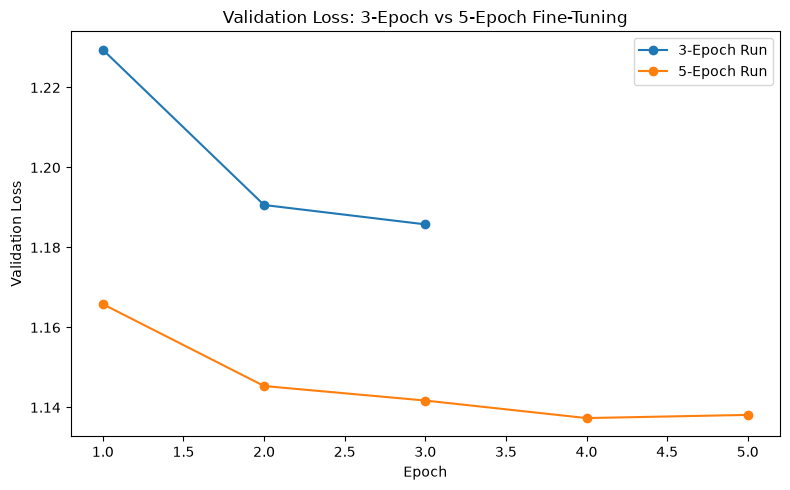

In [55]:
# ============================================================
# 3-Epoch vs 5-Epoch Validation Loss Comparison
# ============================================================

epochs_3 = [1, 2, 3]
validation_loss_3 = [
    1.229441,
    1.190611,
    1.185768
]

epochs_5 = [1, 2, 3, 4, 5]
validation_loss_5 = [
    1.165817,
    1.145333,
    1.141700,
    1.137314,
    1.138108
]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_3,
    validation_loss_3,
    marker="o",
    label="3-Epoch Run"
)

plt.plot(
    epochs_5,
    validation_loss_5,
    marker="o",
    label="5-Epoch Run"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: 3-Epoch vs 5-Epoch Fine-Tuning")
plt.legend()

plt.tight_layout()
plt.show()

### Performance Visualizations

The following charts visualize the improvement from the pretrained baseline through the 3-epoch and 5-epoch fine-tuning experiments.

ROUGE, BLEU, and semantic similarity are shown separately because the metrics use different numerical scales and measure different aspects of summarization quality.

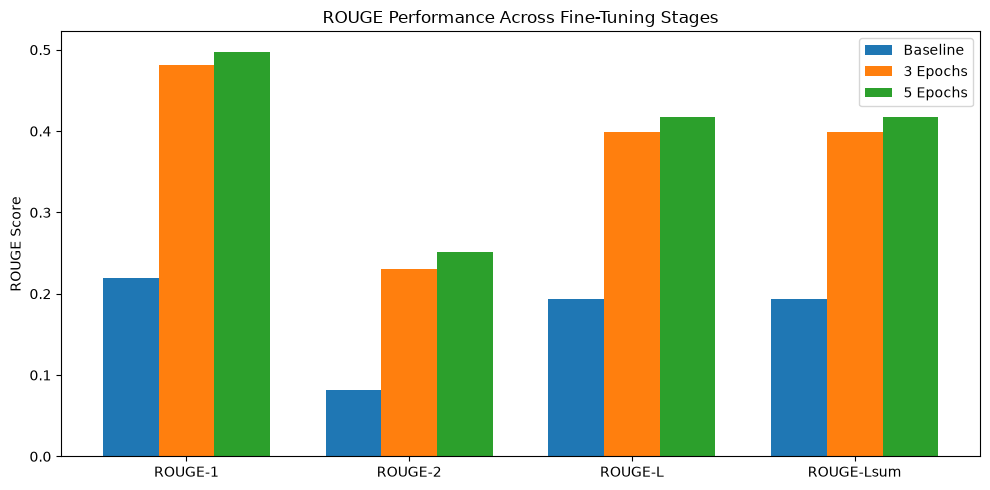

In [57]:
# ============================================================
# ROUGE Comparison: Baseline vs 3 Epochs vs 5 Epochs
# ============================================================

rouge_metrics = [
    "ROUGE-1",
    "ROUGE-2",
    "ROUGE-L",
    "ROUGE-Lsum"
]

baseline_scores = [
    baseline_rouge["rouge1"],
    baseline_rouge["rouge2"],
    baseline_rouge["rougeL"],
    baseline_rouge["rougeLsum"]
]

three_epoch_scores = [
    fine_tuned_rouge["rouge1"],
    fine_tuned_rouge["rouge2"],
    fine_tuned_rouge["rougeL"],
    fine_tuned_rouge["rougeLsum"]
]

five_epoch_scores = [
    five_epoch_rouge["rouge1"],
    five_epoch_rouge["rouge2"],
    five_epoch_rouge["rougeL"],
    five_epoch_rouge["rougeLsum"]
]

x = np.arange(len(rouge_metrics))
bar_width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - bar_width,
    baseline_scores,
    bar_width,
    label="Baseline"
)

plt.bar(
    x,
    three_epoch_scores,
    bar_width,
    label="3 Epochs"
)

plt.bar(
    x + bar_width,
    five_epoch_scores,
    bar_width,
    label="5 Epochs"
)

plt.xticks(x, rouge_metrics)
plt.ylabel("ROUGE Score")
plt.title(
    "ROUGE Performance Across Fine-Tuning Stages"
)
plt.legend()

plt.tight_layout()
plt.show()

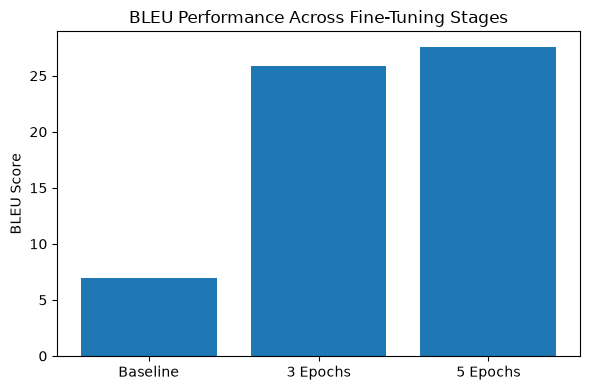

In [58]:
# ============================================================
# BLEU Comparison: Baseline vs 3 Epochs vs 5 Epochs
# ============================================================

bleu_labels = [
    "Baseline",
    "3 Epochs",
    "5 Epochs"
]

bleu_scores = [
    baseline_bleu["score"],
    fine_tuned_bleu["score"],
    five_epoch_bleu["score"]
]

plt.figure(figsize=(6, 4))

plt.bar(
    bleu_labels,
    bleu_scores
)

plt.ylabel("BLEU Score")
plt.title(
    "BLEU Performance Across Fine-Tuning Stages"
)

plt.tight_layout()
plt.show()

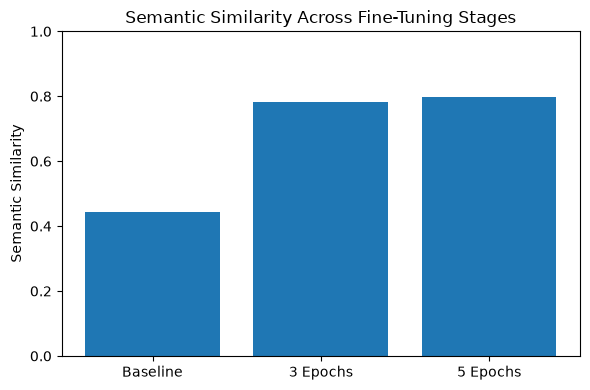

In [59]:
# ============================================================
# Semantic Similarity Comparison:
# Baseline vs 3 Epochs vs 5 Epochs
# ============================================================

semantic_labels = [
    "Baseline",
    "3 Epochs",
    "5 Epochs"
]

semantic_scores = [
    baseline_semantic_similarity,
    fine_tuned_semantic_similarity,
    five_epoch_semantic_similarity
]

plt.figure(figsize=(6, 4))

plt.bar(
    semantic_labels,
    semantic_scores
)

plt.ylabel("Semantic Similarity")
plt.title(
    "Semantic Similarity Across Fine-Tuning Stages"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## 16. Quantized Inference with 8-Bit Metal Quantization

The final 5-epoch fine-tuned model is evaluated using **8-bit weight quantization** as a deployment-oriented optimization for Apple Silicon hardware.

Full fine-tuning is performed using the standard model weights because FLAN-T5-Small can be trained successfully on the available hardware. Quantization is applied after fine-tuning so that its impact on inference efficiency and model quality can be evaluated independently.

Hugging Face Metal quantization is used with:

- **Weight precision:** 8-bit
- **Group size:** 64
- **Execution device:** MPS
- **Model:** 5-epoch fine-tuned FLAN-T5-Small

The quantized model is evaluated on the same 500 unique test dialogues using the same generation configuration and evaluation metrics as the full-precision model.

The objective is to determine whether 8-bit quantization can reduce model memory requirements while preserving acceptable summarization quality.

In [61]:
%pip install -q kernels

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ============================================================
# Load Final Model with 8-Bit Metal Quantization
# ============================================================

from transformers import AutoModelForSeq2SeqLM, MetalConfig

# 8-bit quantization provides a less aggressive compression
metal_config_8bit = MetalConfig(
    bits=8,
    group_size=64
)

quantized_model_8bit = AutoModelForSeq2SeqLM.from_pretrained(
    FIVE_EPOCH_MODEL_PATH,
    quantization_config=metal_config_8bit,
    device_map="mps"
)

quantized_model_8bit.eval()

print("8-bit quantized model loaded successfully.")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


8-bit quantized model loaded successfully.


In [66]:
# ============================================================
# 8-Bit Quantized Model Sanity Check
# ============================================================

sample_dialogue = unique_test_dialogues[0]

prompt = "Summarize the following dialogue: " + sample_dialogue

inputs = tokenizer(
    prompt,
    return_tensors="pt",
    max_length=MAX_INPUT_LENGTH,
    truncation=True
).to(DEVICE)

with torch.no_grad():
    quantized_8bit_output_ids = quantized_model_8bit.generate(
        **inputs,
        max_new_tokens=MAX_TARGET_LENGTH,
        num_beams=4
    )

quantized_8bit_summary = tokenizer.decode(
    quantized_8bit_output_ids[0],
    skip_special_tokens=True
)

print("Reference Summary:")
print(test_references[sample_dialogue][0])

print("\nFull-Precision 5-Epoch Summary:")
print(five_epoch_predictions[0])

print("\n8-Bit Quantized Summary:")
print(quantized_8bit_summary)

Reference Summary:
Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.

Full-Precision 5-Epoch Summary:
#Person1# asks Ms. Dawson to take a dictation for Ms. Dawson. Ms. Dawson tells #Person1# that all office communications are restricted to email correspondence and official memos. Ms. Dawson tells #Person1# that the use of instant Message programs by employees during working hours is strictly prohibited.

8-Bit Quantized Summary:
Ms. Dawson asks Ms. Dawson to take a dictation for Ms. Dawson. Ms. Dawson asks Ms. Dawson to take a dictation for Ms. Dawson. Ms. Dawson tells Ms. Dawson that all office communications are restricted to email correspondence and official memos. Ms. Dawson tells Ms. Dawson that the use of Instant Message programs by employees during working hours is strictly prohibited.


In [67]:
# ============================================================
# Generate Predictions Using the 8-Bit Quantized Model
# ============================================================

eight_bit_predictions = []
eight_bit_references = []

quantized_model_8bit.eval()

for dialogue in tqdm(
    unique_test_dialogues,
    desc="Generating 8-bit quantized summaries"
):
    prompt = "Summarize the following dialogue: " + dialogue

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = quantized_model_8bit.generate(
            **inputs,
            max_new_tokens=MAX_TARGET_LENGTH,
            num_beams=4
        )

    prediction = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    eight_bit_predictions.append(prediction)
    eight_bit_references.append(
        test_references[dialogue]
    )

print(
    f"8-bit predictions generated: "
    f"{len(eight_bit_predictions)}"
)

print(
    f"Reference groups prepared: "
    f"{len(eight_bit_references)}"
)

Generating 8-bit quantized summaries:   0%|          | 0/500 [00:00<?, ?it/s]

8-bit predictions generated: 500
Reference groups prepared: 500


### 8-Bit Quantized Model Metrics

The summaries generated by the 8-bit quantized model are evaluated using the same metrics applied to the full-precision model.

This allows the effect of quantization on summarization quality to be measured consistently.



In [68]:
# ============================================================
# 8-Bit Quantized ROUGE Evaluation
# ============================================================

eight_bit_rouge = rouge_metric.compute(
    predictions=eight_bit_predictions,
    references=eight_bit_references,
    use_stemmer=True
)

print("8-Bit Quantized ROUGE Scores")

for metric_name, score in eight_bit_rouge.items():
    print(f"{metric_name}: {score:.4f}")


# ============================================================
# 8-Bit Quantized BLEU Evaluation
# ============================================================

eight_bit_bleu = bleu_metric.compute(
    predictions=eight_bit_predictions,
    references=eight_bit_references
)

print("\n8-Bit Quantized BLEU Score")
print(f"BLEU: {eight_bit_bleu['score']:.2f}")


# ============================================================
# 8-Bit Quantized Semantic Similarity Evaluation
# ============================================================

eight_bit_semantic_scores = calculate_semantic_similarity(
    eight_bit_predictions,
    eight_bit_references,
    semantic_model
)

eight_bit_semantic_similarity = np.mean(
    eight_bit_semantic_scores
)

print(
    "\n8-Bit Quantized Semantic Similarity: "
    f"{eight_bit_semantic_similarity:.4f}"
)

8-Bit Quantized ROUGE Scores
rouge1: 0.4891
rouge2: 0.2396
rougeL: 0.4097
rougeLsum: 0.4097

8-Bit Quantized BLEU Score
BLEU: 27.58

8-Bit Quantized Semantic Similarity: 0.7891


### Full-Precision vs 8-Bit Quantized Model

The 8-bit quantized model was compared with the full-precision 5-epoch model using the same 500 unique test dialogues, reference summaries, prompt format, and generation configuration.

| Metric | Full-Precision 5-Epoch | 8-Bit Quantized |
|---|---:|---:|
| ROUGE-1 | **0.4978** | 0.4891 |
| ROUGE-2 | **0.2510** | 0.2396 |
| ROUGE-L | **0.4176** | 0.4097 |
| ROUGE-Lsum | **0.4175** | 0.4097 |
| BLEU | **27.58** | **27.58** |
| Semantic Similarity | **0.7968** | 0.7891 |

The 8-bit model retains most of the summarization quality of the full-precision model.

A small reduction is observed across the ROUGE and semantic similarity metrics, while the BLEU score remains unchanged.

These results indicate that 8-bit post-training quantization provides a practical trade-off between model efficiency and output quality. The model continues to generate meaningful dialogue summaries while operating with reduced weight precision.

For this experiment, the full-precision 5-epoch model remains the highest-quality configuration, while the 8-bit quantized model represents the preferred deployment-oriented alternative when memory efficiency is a priority.

This demonstrates that quantization should be evaluated not only in terms of compression, but also in terms of its effect on downstream task quality.

### Quantization Efficiency – Model Memory Footprint

To evaluate the practical benefit of 8-bit quantization, the approximate in-memory model footprint is compared between:

- the full-precision 5-epoch model, and
- the 8-bit quantized model.

This comparison helps quantify the deployment advantage of reduced-weight precision in addition to measuring output quality.

The reported values represent the memory required by model parameters and buffers and therefore provide an approximate view of the model footprint during inference.

### Quantized Inference Sanity Check

Before running evaluation across the complete test set, a single dialogue is used to verify that the **8-bit quantized model** loads correctly and produces a valid summary on the MPS device.

This sanity check confirms that the quantized inference pipeline is functioning before full benchmarking.

In [69]:
# ============================================================
# Compare Model Memory Footprint
# ============================================================

def get_model_memory_mb(model):
    """
    Estimate the memory occupied by model parameters
    and registered buffers.
    """

    parameter_bytes = sum(
        parameter.numel() * parameter.element_size()
        for parameter in model.parameters()
    )

    buffer_bytes = sum(
        buffer.numel() * buffer.element_size()
        for buffer in model.buffers()
    )

    total_bytes = parameter_bytes + buffer_bytes

    return total_bytes / (1024 ** 2)


full_precision_memory = get_model_memory_mb(model_5epoch)
eight_bit_memory = get_model_memory_mb(quantized_model_8bit)

memory_reduction = (
    (full_precision_memory - eight_bit_memory)
    / full_precision_memory
) * 100

print(
    f"Full-Precision Model Memory: "
    f"{full_precision_memory:.2f} MB"
)

print(
    f"8-Bit Quantized Model Memory: "
    f"{eight_bit_memory:.2f} MB"
)

print(
    f"Approximate Memory Reduction: "
    f"{memory_reduction:.2f}%"
)

Full-Precision Model Memory: 293.58 MB
8-Bit Quantized Model Memory: 195.83 MB
Approximate Memory Reduction: 33.30%


### Quantization Efficiency – Interpretation

The approximate in-memory model footprint decreased from **293.58 MB** for the full-precision model to **195.83 MB** for the 8-bit quantized model.

This represents an estimated **33.30% reduction in model parameter and buffer memory**.

Combined with the evaluation results, the experiment demonstrates a favorable deployment trade-off:

- approximately **33% lower measured model memory footprint**,
- only small reductions in ROUGE and semantic similarity,
- and no observed reduction in BLEU.

The full-precision 5-epoch model remains the preferred configuration when maximum summarization quality is the primary objective. The 8-bit model is a practical alternative when memory efficiency and local deployment constraints are more important.

The reported memory values represent model parameters and buffers in the current runtime and should not be interpreted as total application memory consumption.

## 17. Hallucination and Error Analysis

Large Language Models can generate fluent and plausible information that is not supported by the source input or verified facts. This behavior is commonly referred to as **hallucination**.

Hallucination is not limited to summarization. It can occur in question answering, retrieval-based assistants, customer support, legal or healthcare applications, code generation, and other enterprise AI systems.

### Common Situations in Which LLMs Hallucinate

Hallucination is more likely when:

- **Input is incomplete or ambiguous:** the model may attempt to fill missing context with plausible but unsupported information.
- **Queries are highly specialized or out of domain:** the model may have insufficient exposure to the required terminology or business rules.
- **Context is long or complex:** relationships between multiple entities or events can be confused.
- **Entity or speaker attribution is difficult:** information may be assigned to the wrong person or organization.
- **Reliable grounding is unavailable:** the model may rely only on statistical patterns learned during pretraining.
- **Generation is highly open-ended:** fewer constraints provide more opportunity for unsupported content.

### Errors Observed in This Experiment

Although fine-tuning substantially improved summarization performance, qualitative review identified several remaining failure modes:

- incorrect speaker attribution,
- unsupported factual additions,
- incomplete coverage of important dialogue information,
- and repetition.

These observations reinforce an important limitation of automated metrics: higher ROUGE, BLEU, or semantic similarity scores do not necessarily guarantee factual correctness.

### How Fine-Tuning Can Help

Fine-tuning on high-quality, task-specific or domain-specific data can reduce hallucination by adapting the model to the expected terminology, relationships, output structure, and behavior of a particular use case.

In this experiment, DialogSum provides supervised dialogue-summary pairs that teach the model which information is important and how it should be represented in a concise summary.

High-quality fine-tuning can improve:

- task understanding,
- domain terminology,
- output consistency,
- relevant information selection,
- and contextual accuracy.

However, fine-tuning should be treated as a **hallucination risk-reduction technique rather than a complete factuality solution**.

### Additional Mitigation Techniques

For production systems, fine-tuning can be combined with additional safeguards:

- **Data curation:** remove inaccurate, contradictory, or low-quality training examples.
- **Grounded prompting:** instruct the model to use only information available in the source.
- **Retrieval-Augmented Generation (RAG):** provide trusted external context for knowledge-intensive tasks.
- **Controlled generation:** apply suitable decoding constraints to reduce repetition or overly open-ended generation.
- **Factual validation:** check generated claims, entities, dates, or amounts against the source.
- **Human review:** retain human oversight for high-impact workflows.
- **Monitoring and feedback:** track factual errors and use validated failures to improve future model versions.

### Key Takeaway

Fine-tuning substantially improved dialogue summarization quality in this experiment, but it did not completely eliminate factual errors.

A reliable enterprise solution should therefore combine **high-quality data, task-specific fine-tuning, grounding where required, factual validation, monitoring, and appropriate human oversight**.

## 18. Use Cases and Business Applications of Fine-Tuning

Fine-tuning is most valuable when an organization has a clearly defined, repeatable task and access to high-quality examples that represent the expected business behavior.

### When Companies May Consider Fine-Tuning

Common scenarios include:

- **Domain-specific summarization:** customer-service conversations, insurance claim notes, legal documents, technical support logs, or internal reports.
- **Customer-service automation:** generating responses that follow organization-specific tone, terminology, and escalation rules.
- **Information extraction:** identifying structured fields, entities, classifications, or actions from domain-specific text.
- **Classification and routing:** assigning support requests, incidents, or documents to the correct business category.
- **Consistent output formatting:** generating responses that follow specific templates, styles, or workflow requirements.

### Benefits of Domain-Specific Fine-Tuning

Domain-specific fine-tuning can improve:

- understanding of specialized terminology,
- consistency of model behavior,
- adherence to expected output formats,
- relevance to business workflows,
- and performance on frequently repeated task patterns.

The DialogSum experiment demonstrates this effect at the task level: the pretrained FLAN-T5-Small model showed inconsistent summarization behavior, while fine-tuning substantially improved its ability to generate dialogue summaries aligned with human references.

### Base Model vs Fine-Tuned Model

| Base Model | Fine-Tuned Model |
|---|---|
| Strong general-purpose capability | Specialized for a defined task or domain |
| No task-specific training cost | Requires representative training data and training effort |
| Easier to adopt for broad use cases | Can provide more consistent task-specific behavior |
| May rely heavily on prompt engineering | Can reduce dependence on complex prompts |
| Easier to update when requirements change | Requires retraining or additional tuning when behavior changes |

Fine-tuning is not always the best solution. If the primary requirement is access to frequently changing external knowledge, techniques such as **Retrieval-Augmented Generation (RAG)** may be more appropriate.

In practice, the two approaches can also be combined: fine-tuning can specialize model behavior, while retrieval provides current or organization-specific knowledge.

### Business ROI

The potential return on investment depends on the scale and value of the workflow being automated.

For example, in a high-volume contact-center environment, a fine-tuned summarization model could automatically generate standardized call summaries. Potential business benefits include:

- reduced manual documentation effort,
- faster case processing,
- more consistent summaries,
- improved downstream analytics,
- and reduced operational cost per interaction.

However, ROI should be evaluated against the cost of preparing training data, model training, infrastructure, monitoring, governance, and ongoing maintenance.

Fine-tuning is therefore most attractive when the task is repeated at sufficient scale and the quality improvement creates measurable operational or business value.

## 19. Responsible AI and Ethical Considerations

Deploying a fine-tuned language model in an enterprise environment requires more than strong benchmark performance. The model must also be evaluated for reliability, fairness, privacy, and appropriate human oversight.

### Hallucination and Factual Reliability

As observed in the qualitative analysis, a model can generate fluent summaries that contain incorrect speaker attribution, unsupported details, or missing information.

For high-impact use cases, generated outputs should therefore be validated against the source content and reviewed by a human when incorrect information could affect business or customer decisions.

### Bias and Fairness

A fine-tuned model can inherit biases from both the pretrained model and the training dataset.

If the training data contains unbalanced representation or biased language patterns, the model may reproduce those patterns in its outputs. Domain-specific models should therefore be evaluated across representative user groups and scenarios before deployment.

### Privacy and Confidentiality

Enterprise fine-tuning datasets may contain personally identifiable, confidential, or regulated information.

Organizations should apply appropriate data-governance controls, including data minimization, anonymization where required, access control, and secure storage of training and inference data.

### Human Oversight

Human review should remain part of workflows where model outputs can influence financial, legal, healthcare, compliance, or other high-impact decisions.

The model should support human decision-making rather than automatically replace accountable decision-makers.

### Monitoring and Governance

Production models should be continuously monitored for:

- changes in output quality,
- hallucination or factual-error rates,
- biased or inappropriate responses,
- data or model drift,
- and unexpected usage patterns.

Model versions, datasets, evaluation results, and significant configuration changes should also be documented to support reproducibility and governance.

### Responsible Deployment Principle

A production-ready fine-tuned LLM should balance **model quality, factual reliability, privacy, fairness, transparency, monitoring, and appropriate human oversight**.

## 20. Future Improvements

The experiment demonstrates that fine-tuning substantially improves dialogue summarization performance, but several areas could be explored further.

### 1. Hyperparameter Optimization

Additional experiments could evaluate:

- alternative learning rates,
- different effective batch sizes,
- learning-rate schedulers,
- early stopping,
- and checkpoint selection based on validation performance.

This could help identify a configuration that improves generalization while avoiding unnecessary training.

### 2. Training Data Curation

Although DialogSum provides suitable supervised examples, additional data-quality improvements could include:

- identifying noisy or inconsistent summaries,
- reviewing duplicate training samples,
- balancing dialogue types,
- and adding higher-quality domain-specific examples.

Improving training-data quality may reduce speaker confusion, unsupported details, and other factual errors.

### 3. Speaker-Aware Preprocessing

Several observed errors involve incorrect speaker attribution.

A future preprocessing strategy could explicitly preserve or normalize speaker identifiers so that relationships between statements and speakers are easier for the model to learn.

### 4. Alternative Pretrained Models

The experiment could be repeated with other lightweight sequence-to-sequence models to evaluate whether a different architecture provides better summarization quality or efficiency.

Larger models could also be explored where additional compute is available.

### 5. Parameter-Efficient Fine-Tuning

Full fine-tuning was practical for FLAN-T5-Small in this experiment.

For larger models, techniques such as LoRA or other PEFT approaches could reduce the number of trainable parameters and lower memory requirements while retaining task adaptation.

### 6. Stronger Factuality Evaluation

ROUGE, BLEU, and semantic similarity provide useful quality signals but do not directly measure factual correctness.

Future evaluation could include:

- factual-consistency metrics,
- source-to-summary claim verification,
- speaker-attribution accuracy,
- hallucination-rate tracking,
- and structured human evaluation.

### 7. Production-Oriented Evaluation

Before deployment, additional testing should include:

- inference latency,
- throughput,
- memory consumption,
- robustness to longer or out-of-domain dialogues,
- and monitoring for quality drift.

The 8-bit quantization experiment provides an initial step toward deployment efficiency, but production suitability should be evaluated across both quality and operational metrics.

## 21. Outcome and Conclusion

This case study evaluated whether task-specific fine-tuning could improve the dialogue summarization capability of `google/flan-t5-small` on the DialogSum dataset.

The pretrained baseline demonstrated some general summarization capability, but its behavior was inconsistent and occasionally produced incomplete or poorly structured summaries.

After fine-tuning, performance improved substantially across all evaluation metrics.

### Final Performance

| Metric | Baseline | 5-Epoch Fine-Tuned |
|---|---:|---:|
| ROUGE-1 | 0.2193 | **0.4978** |
| ROUGE-2 | 0.0811 | **0.2510** |
| ROUGE-L | 0.1932 | **0.4176** |
| ROUGE-Lsum | 0.1934 | **0.4175** |
| BLEU | 6.96 | **27.58** |
| Semantic Similarity | 0.4438 | **0.7968** |

The 5-epoch model achieved the strongest held-out test performance and was selected as the final full-precision configuration.

The results show that fine-tuning substantially improved the model's ability to identify important dialogue content and generate summaries that are more closely aligned with human-written references.

### Key Findings

The experiment demonstrated that:

- task-specific fine-tuning produced substantial gains over the pretrained baseline,
- extending training from 3 to 5 epochs provided additional improvement,
- quantitative metrics should be complemented with qualitative review because factual and speaker-attribution errors can still occur,
- and 8-bit quantization can reduce deployment memory requirements while preserving most of the model's summarization quality.

The 8-bit model reduced the approximate model parameter and buffer footprint from **293.58 MB to 195.83 MB**, representing a **33.30% reduction**, while retaining strong evaluation performance.

### Practical Takeaway

Fine-tuning is most valuable when an organization has a clearly defined task, representative high-quality data, and a measurable need for more consistent task-specific model behavior.

For production use, model quality should be evaluated alongside factual reliability, deployment efficiency, monitoring, governance, and appropriate human oversight.

Overall, the experiment demonstrates that a lightweight open-source model can be successfully adapted for dialogue summarization on laptop-class hardware while maintaining a practical balance between model quality and deployment efficiency.